# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Black hole spin (`a`)**  
- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
#REMEMBER TO CHANGE MODEL = "ANALYTIC" in set_globals.jl

Using model: analytic, change src/set_globals.jl to modify.
Available threads: 1


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** with respect to the black hole spin (`a`) and observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethod**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [9]:
using ProgressMeter

ProgressMeter.ijulia_behavior(:clear)

const nx, ny = 128,128
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_da_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

const DX = DY = 30
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, 7.778e3 * PC, L_unit)
const freq = 230e9
const ro = 1000.0
const fovx = fovy = DX / ro
const nmaxstep = 15000
const bhspin = 0.9
const Rout = 1000.0
const Rstop = 10000.0
const th = 60.0
const phi = 0.0

const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)
const params = GlobalParams(bhspin, Rout, cstartx, cstopx);
# Pre-allocate trajectory arrays for each thread
const num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, num_threads)
for tid in 1:num_threads
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end


progress = zeros(Int, Threads.nthreads())
total = nx * ny
p = Progress(
    total; 
    desc = "Computing Image and Sensitivity...", 
    showspeed = true, 
    barlen = 30
)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_da_out = Ref{Float64}(0.0)
        
        AutoDiffGeoTrajEulerMethod!(
            thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
            ro, th, phi, params.a, nx, ny, nmaxstep, i, j, 
            freq, fovx, fovy, Rout, Rstop
        )
        
        dI_da_arr[i + 1, j + 1] = dI_da_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]

        # Update the progress bar
        ProgressMeter.next!(
            p; 
            showvalues = [
                (:thread_id, tid), 
                (:pixel, "($i, $j)"), 
                (:total_done, "$(i*ny + j)/$total")
            ]
        )
    end
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:03:16 (11.99 ms/it)
    thread_id: 1
        pixel: (127, 127)
   total_done: 16383/16384


Plotting the image and the derivatives with proper angular spacing

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/Vn16E/src/scenes.jl:264


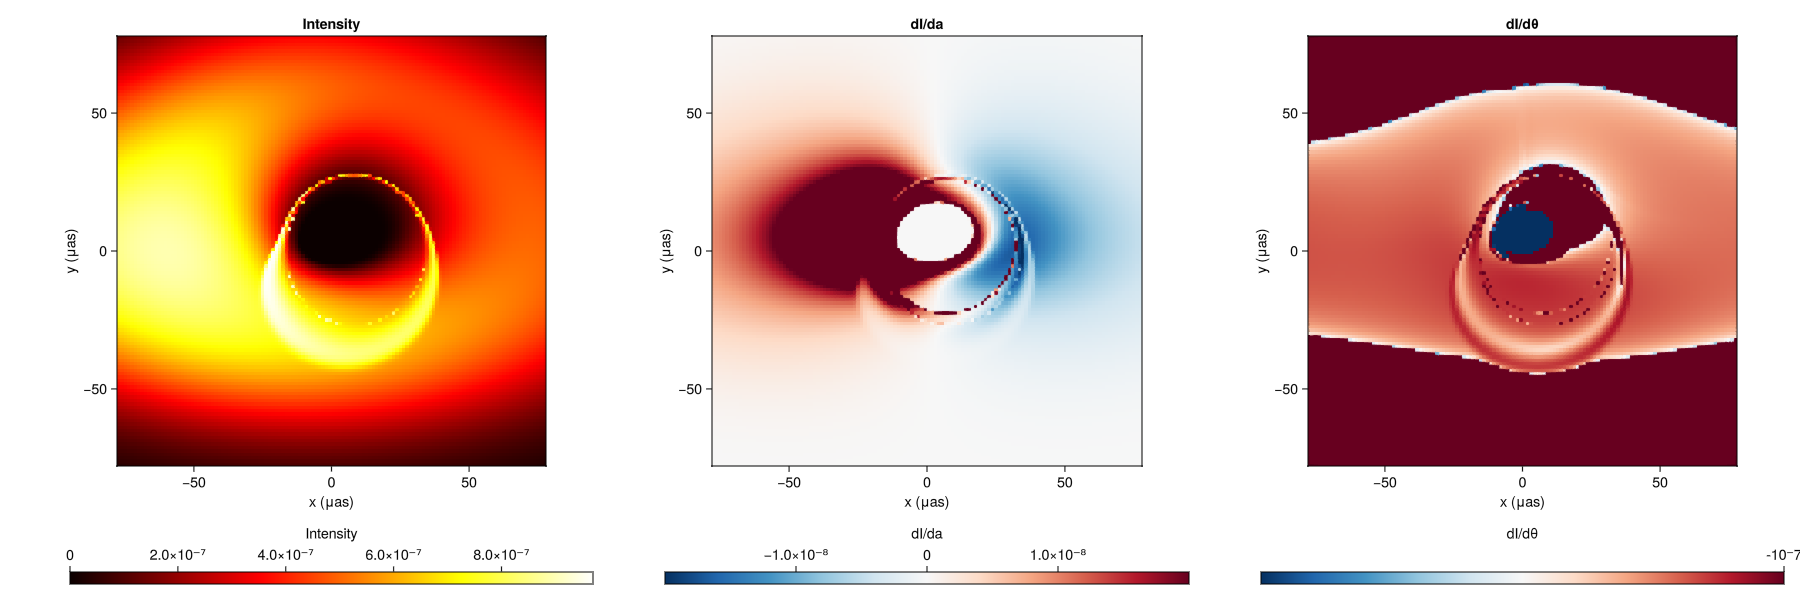

In [10]:
using WGLMakie

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           
fov_rg = 30                      
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * L_unit) / d_cm   
theta_μas = theta_rad * MUAS_PER_RAD      

x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

fig = Figure(resolution=(1800, 600))

ax1 = Axis(fig[1, 1], 
    title="Intensity",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())
    
hm1 = heatmap!(ax1, x_coords, y_coords, I_arr, 
    colormap=:hot)
    
Colorbar(fig[2, 1], hm1, 
    label="Intensity",
    vertical=false)

ax2 = Axis(fig[1, 2], 
    title="dI/da",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())

hm2 = heatmap!(ax2, x_coords, y_coords, dI_da_arr, 
    colormap=Reverse(:RdBu),
    colorrange=(-2e-8, 2e-8))


Colorbar(fig[2, 2], hm2, 
    label="dI/da",
    vertical=false)

ax3 = Axis(fig[1, 3], 
    title="dI/dθ",
    xlabel="x (μas)",
    ylabel="y (μas)",
    aspect=DataAspect())


dI_dθo_transformed = sign.(dI_dθo_arr) .* log10.(abs.(dI_dθo_arr) .+ 1e-12)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dθo_transformed, 
    colormap=Reverse(:RdBu),
    colorrange=(-12, -7)) 

Colorbar(fig[2, 3], hm3, 
    label="dI/dθ",
    vertical=false,
    ticks=[-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7],
    tickformat=values -> [v == 0 ? "0" : v > 0 ? "10⁻$(Int(v))" : "-10⁻$(Int(-v))" for v in values])


fig

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `initial_spin_guess` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `as` → recovered spin values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [12]:
#This will run the conjugate gradient
initial_spin_guess = 0.99
initial_th_guess = 90.0
ths, as, err, steps = true_conjugate_gradient_optimization(I_arr, ro, initial_th_guess, initial_spin_guess, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 6e-14)

Optimization mode: both
Optimizing θo: true, Optimizing a: true
Running AutoDiffGeoTrajEulerMethod with θo = 90.0, a = 0.99 and applying σ_pixels = 0.0 filter
  Convergence check: cost=7.160601137059598e-11, grad_norm=4.8922444934086236e-11
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 7.160601137059598e-11, Initial θo: 90.0, Initial a: 0.99
Initial gradient norm: 4.8922444934086236e-11

--- Iteration 1 ---
Trying aggressive initial step: 6.132154686957968e9, set at iteration 1
Cost before line search: 7.160601137059598e-11
Using cached computation for x = [1.5, 1.6500000000000001]
  Line search: f0=7.160601137059598e-11, df0=-2.3934056183287e-21, initial_step=6.132154686957968e9
Running AutoDiffGeoTrajEulerMethod with θo = 72.10568921051814, a = 0.9705227276821607 and applying σ_pixels = 0.0 filter
  Step 1: step_size=6.132154686957968e9, f_new=1.614816441967901e-11, improvement=5.5457846950916976e-11, spin tested = 0.9705227276821607, θo tested = 72.10

([90.0, 72.10568921051814, 54.11358389403533, 62.47992788873498, 57.992624038305046, 60.22447988356535, 60.112959819418585, 59.222005952624855], [0.99, 0.9705227276821607, 0.9651921903678616, 0.932019478446234, 0.9286415478087482, 0.9257898906418116, 0.9249332305039681, 0.9042723950725406], [7.160601137059598e-11, 1.614816441967901e-11, 1.9327885367624355e-12, 6.034610454379223e-13, 2.9194030655353443e-13, 8.0765709700336e-14, 7.997233339195776e-14, 5.336884840140919e-14], 200)

Plot theta, spin and error evolution at each iteration step

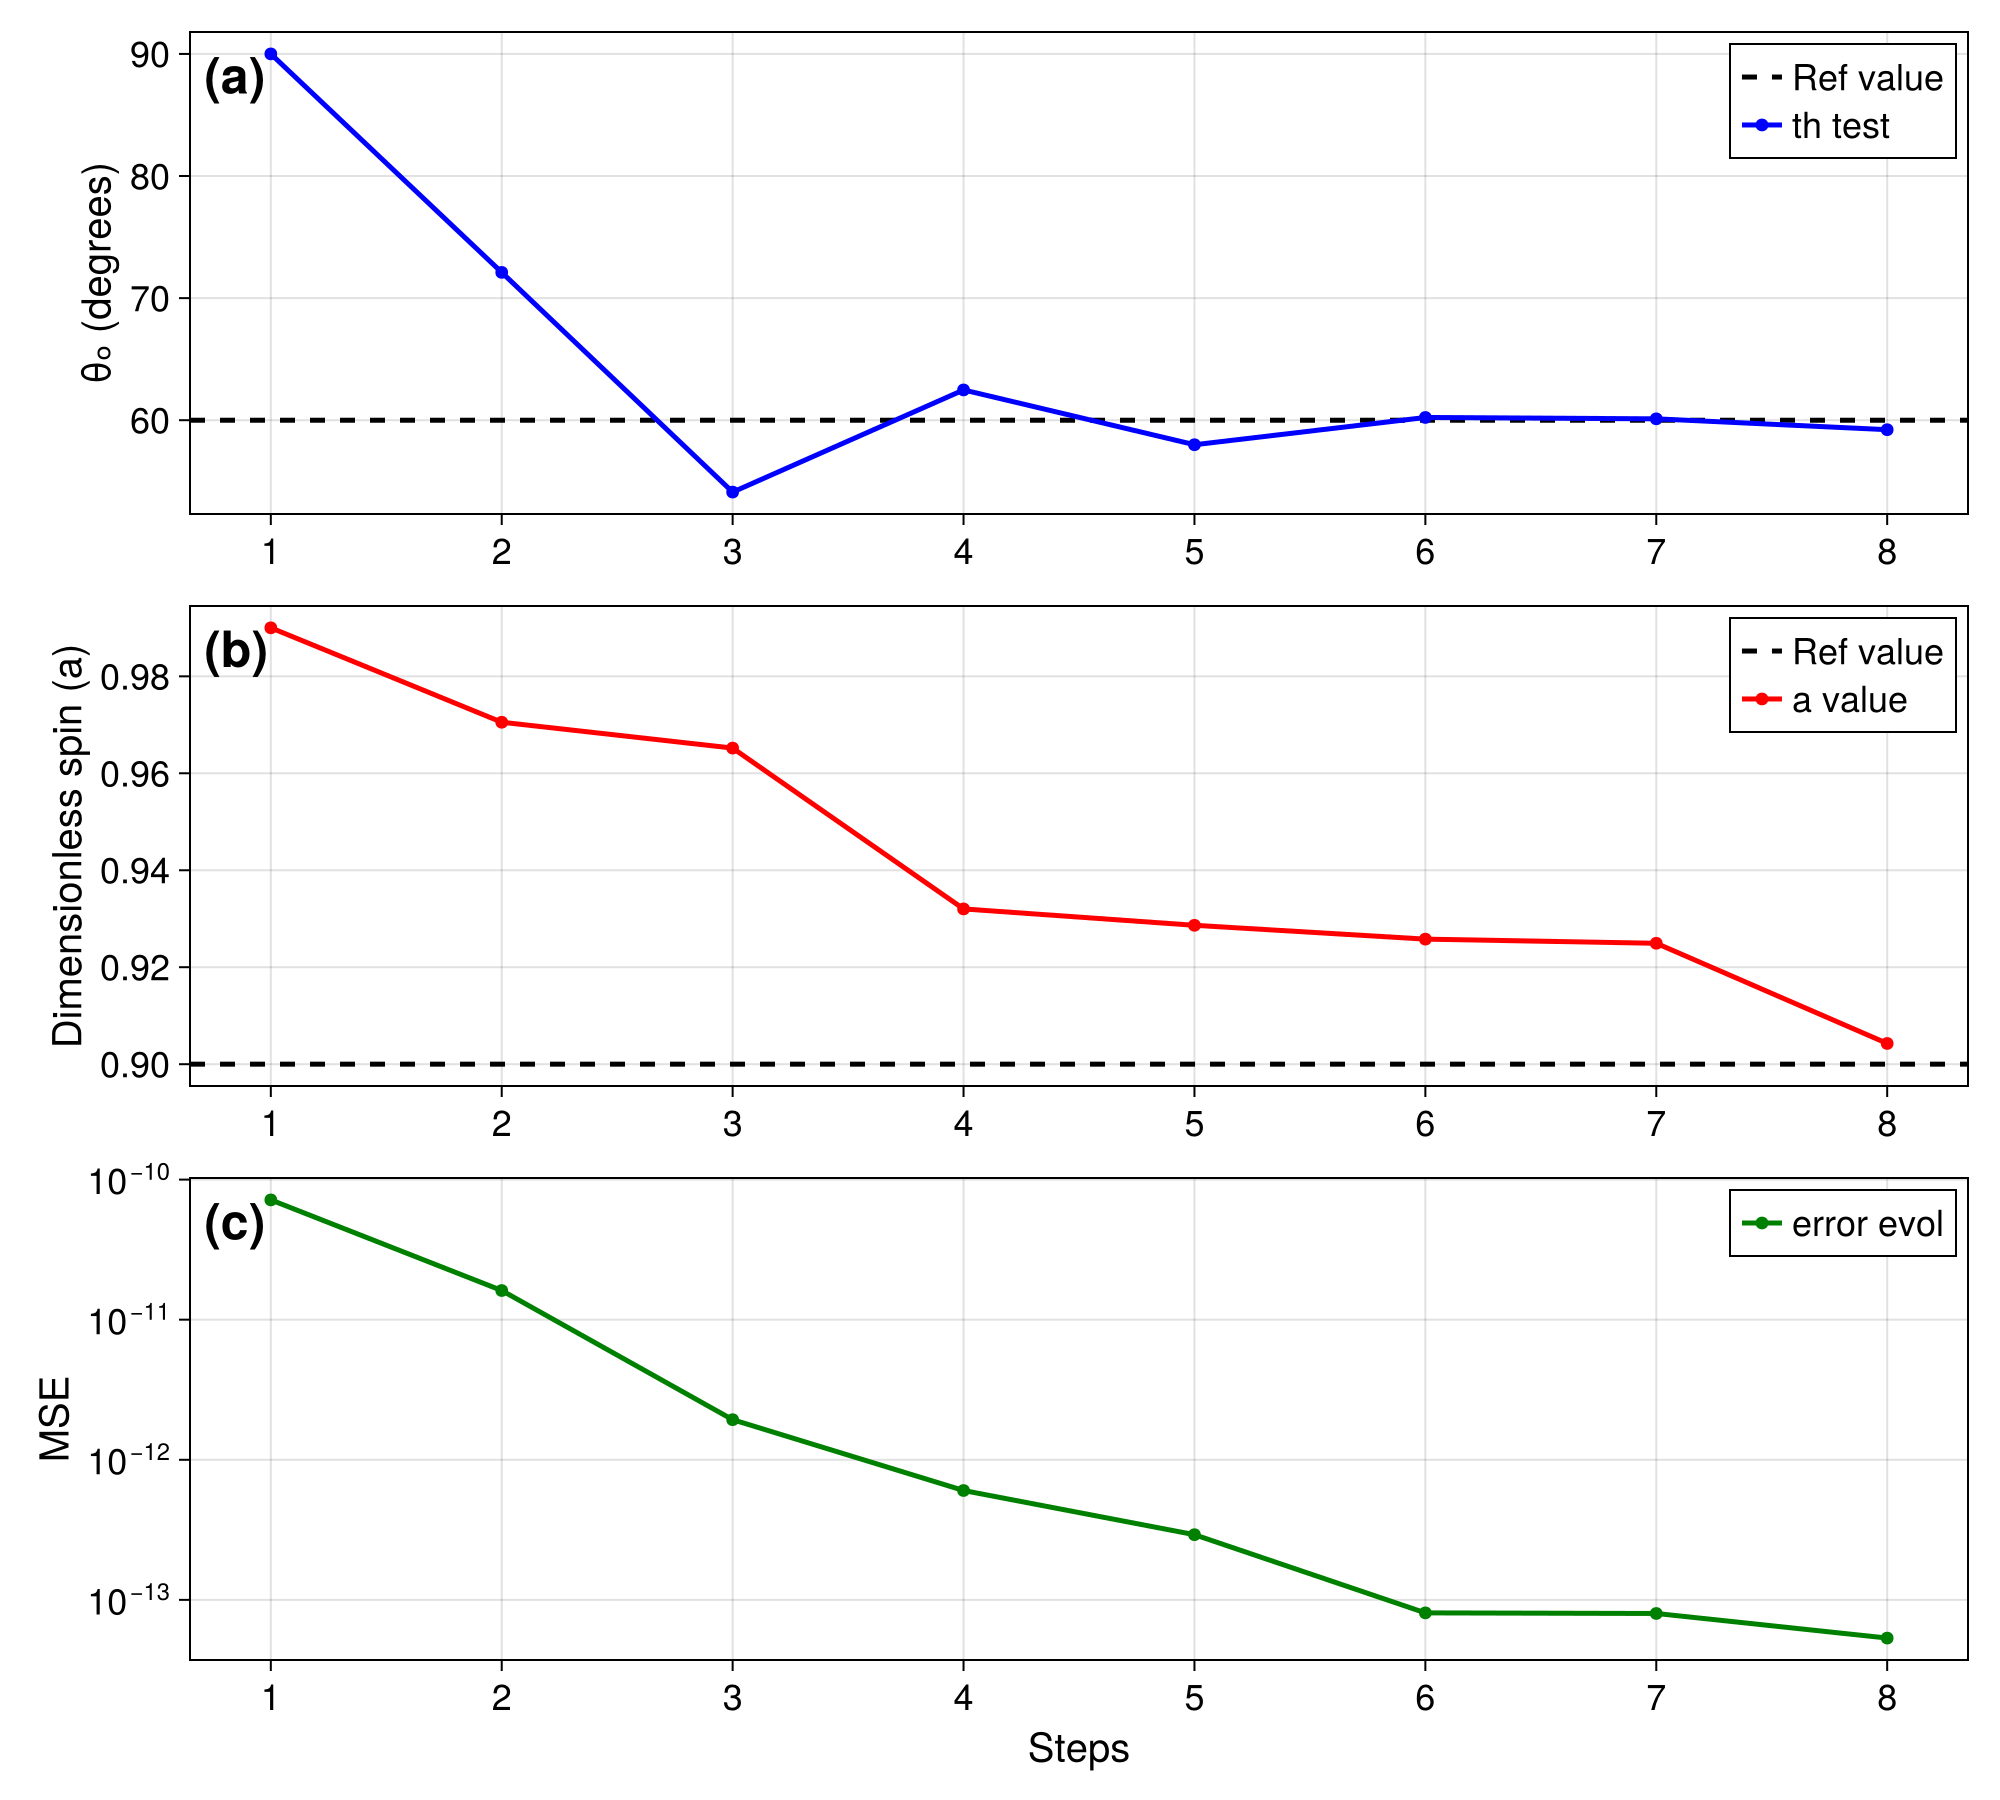

In [52]:
using CairoMakie

fig = Figure(size = (1000, 900))
xticks = 0:9  # Custom x-axis ticks

# (a) Plot θₒ
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# (b) Plot a
ax2 = Axis(fig[2, 1], 
    ylabel = "Dimensionless spin (a)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax2, 0.9, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax2, 1:length(as), as, color = :red, linewidth = 2.5, label = "a value")
axislegend(ax2, position = :rt, labelsize = 18)
text!(ax2, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# (c) Plot Error
ax3 = Axis(fig[3, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(c)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax2, ax3)

# Display and save
#save("../imgs/noise_comparison.png", fig)
fig